In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryCrossentropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2026-03-29 16:17:38.782490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774801058.986557      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774801059.038092      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774801059.486234      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774801059.486274      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774801059.486277      24 computation_placer.cc:177] computation placer alr

In [2]:
base_path = '/kaggle/input/datasets/abhijithc/covid-pneumonia-gray3/covid_pneumonia_gray3'

In [3]:
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

pneumonia: 463
covid: 524


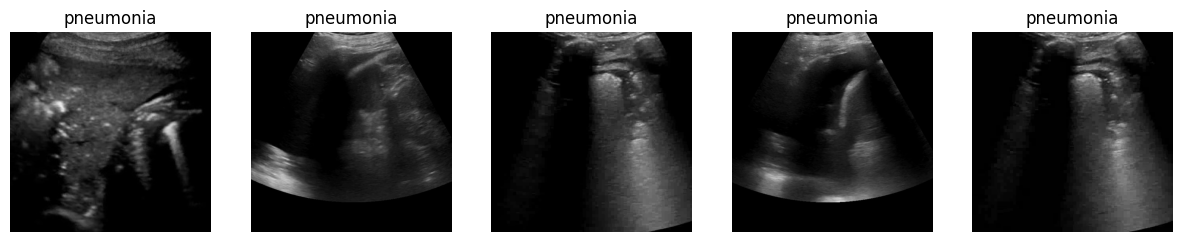

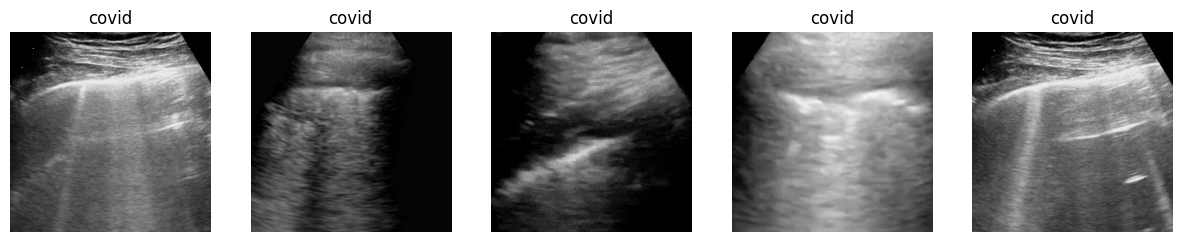

In [4]:
def show_samples(class_path, class_name, n=5):
    images = os.listdir(class_path)
    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        show_samples(cls_path, cls)

In [5]:
def get_video_id(path):
    filename = os.path.basename(path)
    filename = filename.split('.')[0]
    filename = filename.replace('-', '_')
    parts = filename.split('_')
    return '_'.join(parts[:2])

In [6]:
image_paths = []
labels = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)
    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "label": labels
})

df["video_id"] = df["filename"].apply(get_video_id)
df.tail()

,filename,label,video_id
982,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_Atlas
983,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_denault
984,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_recommendations
985,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex
986,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex


In [7]:
video_df = df.groupby("video_id").first().reset_index()

print(video_df['label'].value_counts())

label
covid        11
pneumonia    10
Name: count, dtype: int64


In [8]:
video_sizes = df.groupby("video_id").size()

video_info = video_df.copy()
video_info["num_frames"] = video_info["video_id"].map(video_sizes)

print(video_info.sort_values("num_frames", ascending=False).head(10))

               video_id                                           filename  \
19     Pneu_northumbria  /kaggle/input/datasets/abhijithc/covid-pneumon...   
5            Cov_convex  /kaggle/input/datasets/abhijithc/covid-pneumon...   
0             Cov_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
4        Cov_combatting  /kaggle/input/datasets/abhijithc/covid-pneumon...   
6           Cov_denault  /kaggle/input/datasets/abhijithc/covid-pneumon...   
12             Pneu_Avi  /kaggle/input/datasets/abhijithc/covid-pneumon...   
8   Cov_recommendations  /kaggle/input/datasets/abhijithc/covid-pneumon...   
11           Pneu_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
7            Cov_emdocs  /kaggle/input/datasets/abhijithc/covid-pneumon...   
20      pneu_radiopaeda  /kaggle/input/datasets/abhijithc/covid-pneumon...   

        label  num_frames  
19  pneumonia         272  
5       covid         150  
0       covid          93  
4       covid          88  
6

In [9]:
df = df.groupby("video_id").apply(lambda x: x.sample(n=min(len(x), 50), random_state=42)).reset_index(drop=True)

In [10]:
ggs = GroupShuffleSplit(test_size=0.5, random_state=42)

train_idx, tmp_idx = next(
    ggs.split(df, groups=df["video_id"])
)

train_df = df.iloc[train_idx]
tmp_df = df.iloc[tmp_idx]

ggs2 = GroupShuffleSplit(test_size=0.5, random_state=42)

val_idx, test_idx = next(
    ggs2.split(tmp_df, groups=tmp_df["video_id"])
)

val_df = tmp_df.iloc[val_idx]
test_df = tmp_df.iloc[test_idx]

In [11]:
print("Train:\n", train_df['label'].value_counts(normalize=True))
print("Val:\n", val_df['label'].value_counts(normalize=True))
print("Test:\n", test_df['label'].value_counts(normalize=True))

Train:
 label
covid        0.520446
pneumonia    0.479554
Name: proportion, dtype: float64
Val:
 label
covid        0.862069
pneumonia    0.137931
Name: proportion, dtype: float64
Test:
 label
covid        0.515385
pneumonia    0.484615
Name: proportion, dtype: float64


In [12]:
train_df = pd.DataFrame({
    "x": train_df["filename"],
    "y": train_df["label"]
}) 

val_df = pd.DataFrame({
    "x": val_df["filename"],
    "y": val_df["label"]
})

test_df = pd.DataFrame({
    "x": test_df["filename"],
    "y": test_df["label"]
})

In [13]:
train_df['y'].value_counts()
val_df['y'].value_counts()

y
covid        100
pneumonia     16
Name: count, dtype: int64

In [14]:
train_batches = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
    ).flow_from_dataframe(
    dataframe = train_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    dataframe = val_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

test_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    dataframe = test_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

Found 269 validated image filenames belonging to 2 classes.
Found 116 validated image filenames belonging to 2 classes.
Found 130 validated image filenames belonging to 2 classes.


In [15]:
print(train_batches.class_indices)
print(val_batches.class_indices)
print(test_batches.class_indices)

{'covid': 0, 'pneumonia': 1}
{'covid': 0, 'pneumonia': 1}
{'covid': 0, 'pneumonia': 1}


In [16]:
images, labels = next(train_batches)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..38.957436].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.58121..83.00115].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..144.02841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..145.14551].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..149.37054].


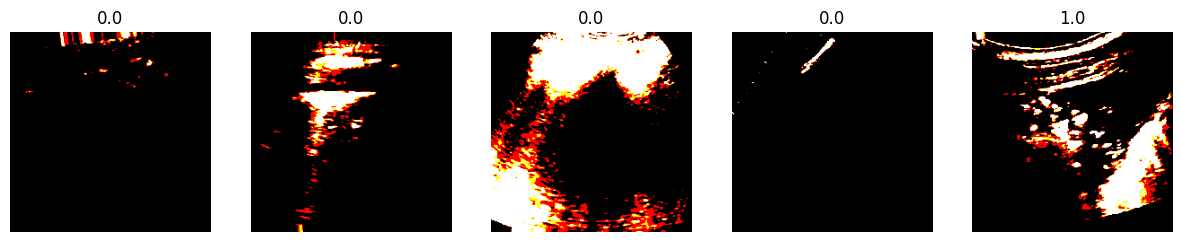

In [17]:
plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [18]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1774801086.322065      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774801086.324859      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
for layer in base_model.layers:
    layer.trainable = False

In [20]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(units=1, activation="sigmoid")
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [23]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [24]:
model.fit(x=train_batches, validation_data=val_batches, epochs=30, callbacks=[early_stop], verbose=2)

Epoch 1/30


I0000 00:00:1774801097.162785      76 service.cc:152] XLA service 0x7d1ddc04c5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774801097.162845      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774801097.162852      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774801099.062308      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774801103.889413      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 - 29s - 3s/step - accuracy: 0.4349 - loss: 1.0778 - val_accuracy: 0.7931 - val_loss: 0.5631
Epoch 2/30
9/9 - 4s - 430ms/step - accuracy: 0.4610 - loss: 0.9698 - val_accuracy: 0.7759 - val_loss: 0.5973
Epoch 3/30
9/9 - 4s - 440ms/step - accuracy: 0.5204 - loss: 0.9058 - val_accuracy: 0.7672 - val_loss: 0.6042
Epoch 4/30
9/9 - 4s - 431ms/step - accuracy: 0.5204 - loss: 0.9018 - val_accuracy: 0.7586 - val_loss: 0.6091
Epoch 5/30
9/9 - 4s - 431ms/step - accuracy: 0.5465 - loss: 0.8471 - val_accuracy: 0.6724 - val_loss: 0.6409
Epoch 6/30
9/9 - 4s - 421ms/step - accuracy: 0.5279 - loss: 0.7769 - val_accuracy: 0.7328 - val_loss: 0.6124


In [25]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_batches)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_batches.classes, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
[[63  4]
 [36 27]]


In [26]:
test_loss, test_acc = model.evaluate(test_batches)
print(test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 0.7889 - loss: 0.4559
0.692307710647583
